In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm


In [4]:
df = pd.read_csv(r"C:\Users\lucab\OneDrive\Documentos\projetos_python\estudo_elasticidade\avocado_prices.csv")
df

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18244,7,2018-02-04,1.63,17074.83,2046.96,1529.20,0.00,13498.67,13066.82,431.85,0.0,organic,2018,WestTexNewMexico
18245,8,2018-01-28,1.71,13888.04,1191.70,3431.50,0.00,9264.84,8940.04,324.80,0.0,organic,2018,WestTexNewMexico
18246,9,2018-01-21,1.87,13766.76,1191.92,2452.79,727.94,9394.11,9351.80,42.31,0.0,organic,2018,WestTexNewMexico
18247,10,2018-01-14,1.93,16205.22,1527.63,2981.04,727.01,10969.54,10919.54,50.00,0.0,organic,2018,WestTexNewMexico


In [33]:
# Criei uma cópia do df filtrado para evitar problemas com alterações
df_california = df[df['region'] == 'California'].copy()
df_california['Date'] = pd.to_datetime(df_california['Date'])
df_california = df_california.sort_values('Date').reset_index(drop=True)
df_california

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,51,2015-01-04,0.93,5777334.90,2843648.26,2267755.26,137479.64,528451.74,477193.38,47882.56,3375.80,conventional,2015,California
1,51,2015-01-04,1.24,142349.77,107490.73,25711.96,2.93,9144.15,9144.15,0.00,0.00,organic,2015,California
2,50,2015-01-11,0.92,6024932.34,2889591.29,2485720.10,103573.42,546047.53,510560.41,31874.03,3613.09,conventional,2015,California
3,50,2015-01-11,1.10,158110.68,123712.51,25975.27,1.47,8421.43,8421.43,0.00,0.00,organic,2015,California
4,49,2015-01-18,1.02,5570915.26,2780859.66,2108450.36,121614.31,559990.93,520299.26,36501.18,3190.49,conventional,2015,California
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
333,2,2018-03-11,1.58,236822.98,32765.76,83573.00,0.00,120484.22,120465.39,18.83,0.00,organic,2018,California
334,1,2018-03-18,1.75,202790.74,29398.11,70514.05,8.08,102870.50,102717.50,153.00,0.00,organic,2018,California
335,1,2018-03-18,1.02,6802084.11,2161037.82,2305253.24,94087.86,2241705.19,2116307.93,38597.17,86800.09,conventional,2018,California
336,0,2018-03-25,1.04,6687009.44,1932162.02,2715163.60,92955.04,1946728.78,1827362.50,37434.21,81932.07,conventional,2018,California


In [35]:
df_conv = df_california[df_california['type'] == 'conventional'].copy()
df_org = df_california[df_california['type'] == 'organic'].copy()

In [36]:
df_conv['AveragePrice'].describe()

count    169.000000
mean       1.105444
std        0.229627
min        0.670000
25%        0.940000
50%        1.080000
75%        1.200000
max        1.780000
Name: AveragePrice, dtype: float64

In [40]:
df_org['AveragePrice'].describe()

count    169.000000
mean       1.685207
std        0.290111
min        1.100000
25%        1.480000
50%        1.620000
75%        1.890000
max        2.580000
Name: AveragePrice, dtype: float64

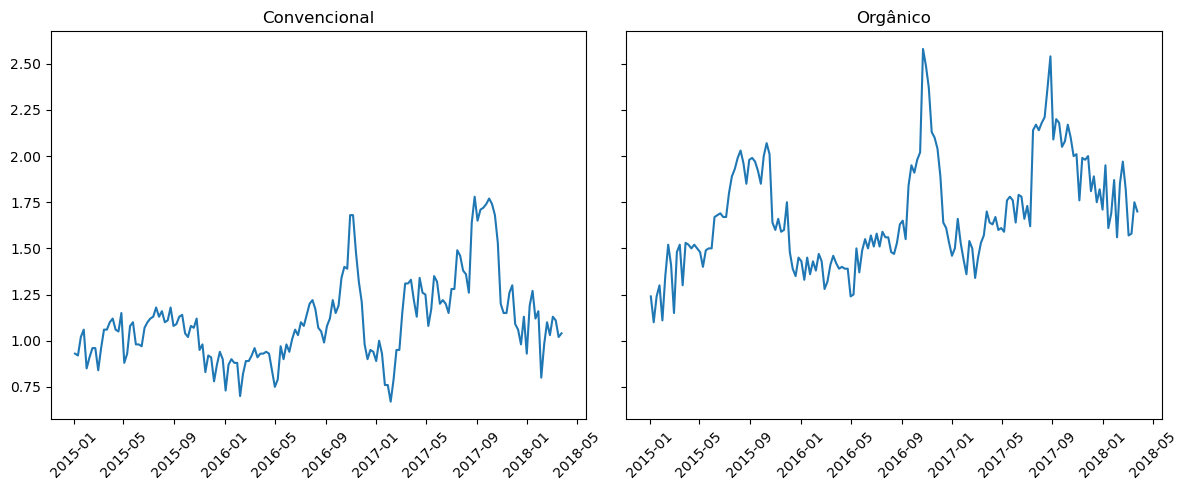

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].plot(df_conv['Date'], df_conv['AveragePrice'])
axes[0].set_title('Convencional')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(df_org['Date'], df_org['AveragePrice'])
axes[1].set_title('Orgânico')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Como próximo passo, vamos fazer a transformação logarítmica. Isso porque a elasticidade preço é a variação percentual na quantidade demandada dividida pela cariação percentual no preço. Regredir o log da quantidade contra o log do preço gera a elasticidade, visto que em log o coeficiente já representa a variação percentual em Y para cada variação percentual em X

In [44]:
df_conv['log_price'] = np.log(df_conv['AveragePrice'])
df_conv['log_qty'] = np.log(df_conv['Total Volume'])

df_org['log_price'] = np.log(df_org['AveragePrice'])
df_org['log_qty'] = np.log(df_org['Total Volume'])

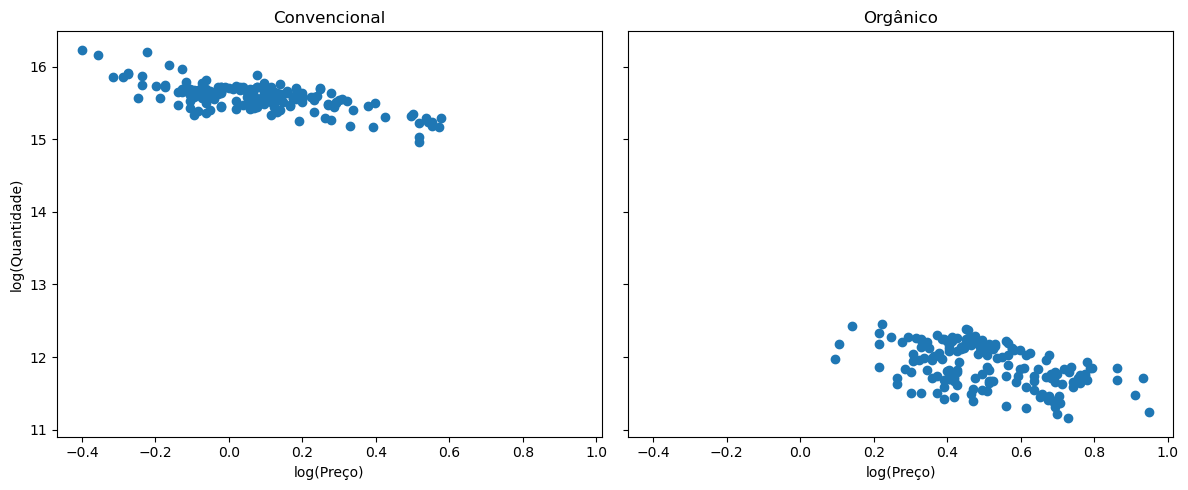

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

axes[0].scatter(df_conv['log_price'], df_conv['log_qty'])
axes[0].set_title('Convencional')
axes[0].set_xlabel('log(Preço)')
axes[0].set_ylabel('log(Quantidade)')

axes[1].scatter(df_org['log_price'], df_org['log_qty'])
axes[1].set_title('Orgânico')
axes[1].set_xlabel('log(Preço)')

plt.tight_layout()
plt.show()

In [49]:
# Convencional
X_conv = sm.add_constant(df_conv['log_price'])
y_conv = df_conv['log_qty']
modelo_conv = sm.OLS(y_conv, X_conv).fit()
print(modelo_conv.summary())

                            OLS Regression Results                            
Dep. Variable:                log_qty   R-squared:                       0.504
Model:                            OLS   Adj. R-squared:                  0.501
Method:                 Least Squares   F-statistic:                     169.9
Date:                Mon, 21 Sep 2026   Prob (F-statistic):           3.10e-27
Time:                        23:59:09   Log-Likelihood:                 101.33
No. Observations:                 169   AIC:                            -198.7
Df Residuals:                     167   BIC:                            -192.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         15.6338      0.011   1407.695      0.0

In [50]:
# Orgânico
X_org = sm.add_constant(df_org['log_price'])
y_org = df_org['log_qty']
modelo_org = sm.OLS(y_org, X_org).fit()
print(modelo_org.summary())

                            OLS Regression Results                            
Dep. Variable:                log_qty   R-squared:                       0.228
Model:                            OLS   Adj. R-squared:                  0.223
Method:                 Least Squares   F-statistic:                     49.32
Date:                Mon, 21 Sep 2026   Prob (F-statistic):           5.23e-11
Time:                        23:59:13   Log-Likelihood:                -9.6248
No. Observations:                 169   AIC:                             23.25
Df Residuals:                     167   BIC:                             29.51
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.2999      0.063    194.625      0.0

In [51]:
modelo_conv_hac = sm.OLS(y_conv, X_conv).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(modelo_conv_hac.summary())

                            OLS Regression Results                            
Dep. Variable:                log_qty   R-squared:                       0.504
Model:                            OLS   Adj. R-squared:                  0.501
Method:                 Least Squares   F-statistic:                     55.43
Date:                Tue, 22 Sep 2026   Prob (F-statistic):           4.91e-12
Time:                        00:03:50   Log-Likelihood:                 101.33
No. Observations:                 169   AIC:                            -198.7
Df Residuals:                     167   BIC:                            -192.4
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         15.6338      0.020    763.005      0.0

In [52]:
modelo_org_hac = sm.OLS(y_org, X_org).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(modelo_org_hac.summary())

                            OLS Regression Results                            
Dep. Variable:                log_qty   R-squared:                       0.228
Model:                            OLS   Adj. R-squared:                  0.223
Method:                 Least Squares   F-statistic:                     20.28
Date:                Tue, 22 Sep 2026   Prob (F-statistic):           1.25e-05
Time:                        00:05:34   Log-Likelihood:                -9.6248
No. Observations:                 169   AIC:                             23.25
Df Residuals:                     167   BIC:                             29.51
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.2999      0.105    116.648      0.0

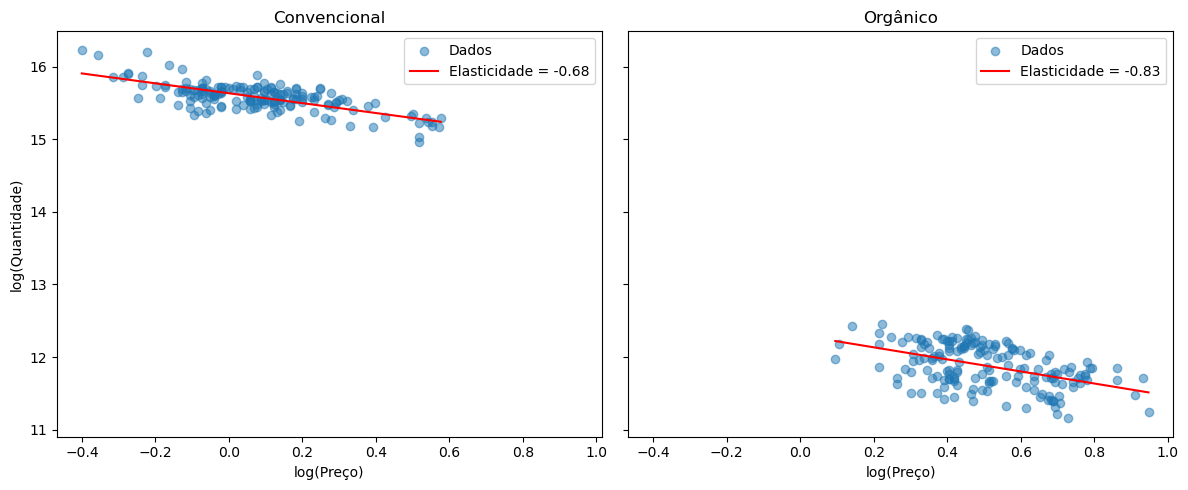

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Convencional
axes[0].scatter(df_conv['log_price'], df_conv['log_qty'], alpha=0.5, label='Dados')
x_range = np.linspace(df_conv['log_price'].min(), df_conv['log_price'].max(), 100)
y_pred = modelo_conv_hac.params['const'] + modelo_conv_hac.params['log_price'] * x_range
axes[0].plot(x_range, y_pred, color='red', label=f'Elasticidade = {modelo_conv_hac.params["log_price"]:.2f}')
axes[0].set_title('Convencional')
axes[0].set_xlabel('log(Preço)')
axes[0].set_ylabel('log(Quantidade)')
axes[0].legend()

# Orgânico
axes[1].scatter(df_org['log_price'], df_org['log_qty'], alpha=0.5, label='Dados')
x_range_org = np.linspace(df_org['log_price'].min(), df_org['log_price'].max(), 100)
y_pred_org = modelo_org_hac.params['const'] + modelo_org_hac.params['log_price'] * x_range_org
axes[1].plot(x_range_org, y_pred_org, color='red', label=f'Elasticidade = {modelo_org_hac.params["log_price"]:.2f}')
axes[1].set_title('Orgânico')
axes[1].set_xlabel('log(Preço)')
axes[1].legend()

plt.tight_layout()
plt.show()

Obs: faz sentido termos log_preço negativo. Isso significa somente que o preço original é menor do que 1. 